In [34]:

import os 
import sys
import pandas as pd 
import seaborn as sns 
import matplotlib as plt
import numpy as np 

sys.path.append("../")
PATH = "../../"

In [43]:
''' 
Prepare data --> change here for different setups!
'''

### Feature selected vars
target="gender"
percentBoruta = 100
varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"

### Manually selected vars
# varFolder = "manual_selection"
# var = f"allVars_mgfaRecoded"  

''' 
Read data
'''
metrics = ["precision",
                            "recall",
                            "f1",
                            "accuracy",
                            "model",
                            "auc",
                            "average_prec"]

PATH_res = f"{PATH}/results/30_predictions/{varFolder}/{var}/modelComparison"
df = pd.read_csv(f"{PATH_res}/prediction_cv_test_rfc.csv")
df.index = metrics
df = df.T
df.drop(["model"], axis=1, inplace=True)
df = df.astype("float64")

# Table + calculate CI

In [51]:
df["precision"].quantile

# confidence intervals
alpha = 0.95

dic_CI = dict()

for i in df.columns:
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(df[i], p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(df[i], p))

    dic_CI[i] = [lower*100, df[i].mean()*100, upper*100]

df_CI = pd.DataFrame.from_dict(dic_CI)
df_CI.index = ["lower CI", "mean", "upper CI"]
df_CI

,precision,recall,f1,accuracy,auc,average_prec
lower CI,62.184332,66.552017,66.518393,60.666782,65.118450,70.379243
mean,68.373620,74.098613,70.995959,66.045963,71.270589,75.265804
upper CI,73.202916,82.020489,73.590057,69.588215,75.053761,79.149334


# Plot 

<Axes: >

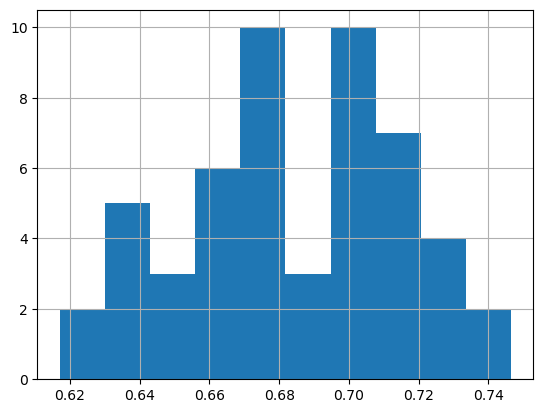

In [52]:
df["precision"].hist()